sales summary
       product_name  total_quantity  total_revenue
0       dumbell set              24         1680.0
1      fitness band              30         1500.0
2  resistance bands              60          900.0
3         treadmill              15         7500.0
4          yoga mat              45         1350.0


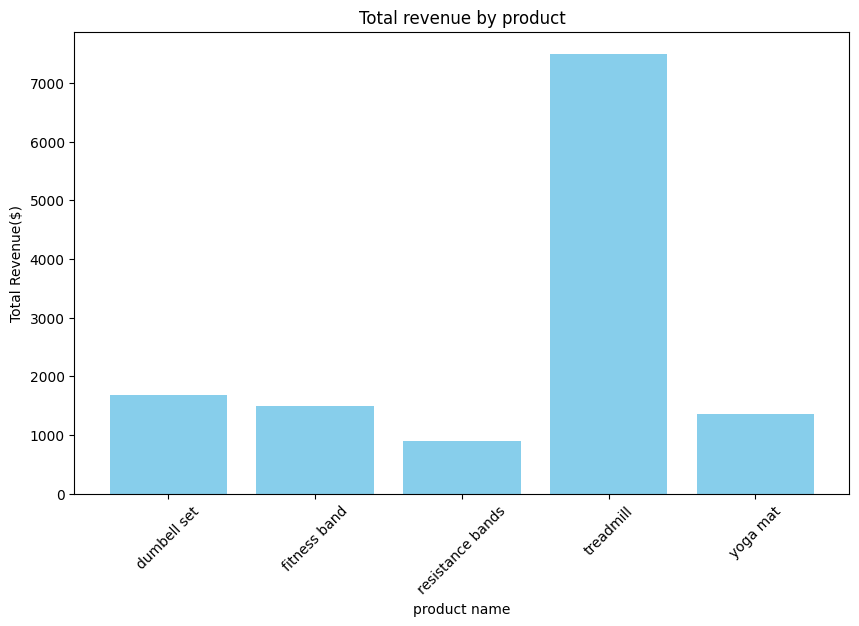

In [ ]:
import sqlite3
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore

conn= sqlite3.connect('sales_data.db')
cursor= conn.cursor()

cursor.execute('''
create table sales(
id integer primary key,
product_name text,
quantity integer,
price_per_unit real)
''')

cursor.executemany("insert into sales(product_name, quantity, price_per_unit)values(?,?,?)",
                   [
                       ('fitness band',10,50),
                       ('yoga mat', 15, 30),
                       ('dumbell set', 8,70),
                       ('treadmill', 5, 500),
                       ('resistance bands', 20, 15)

                   ])
conn.commit()

query= '''select product_name,
sum(quantity) as total_quantity,
sum(quantity*price_per_unit) as total_revenue
from sales
group by product_name'''

df= pd.read_sql(query, conn)
print("sales summary")
print(df)

plt.figure(figsize=(10,6))
plt.bar(df['product_name'], df['total_revenue'], color= 'skyblue')
plt.xlabel('product name')
plt.ylabel('Total Revenue($)')
plt.title('Total revenue by product')
plt.xticks(rotation=45)
plt.show()
conn.close()
